<a href="https://colab.research.google.com/github/suyogbastakoti/Ai-and-Ml-Module/blob/main/Tutorial7_Devanagari_Denoising_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Suyog Bastakoti**

**Uni Id: 2407093**

# 6CS012 - Tutorial 7: Exercise 4
# Denoising Convolutional Autoencoder — Devanagari Handwritten Digit Dataset

**Module:** Artificial Intelligence and Machine Learning  
**Prepared by:** Student Submission  
**Reference:** Siman Giri (Module Leader - 6CS012)

---

## Objective
Build a **Denoising Convolutional Autoencoder** with at least **4 layers deep** to remove noise from images in the Devanagari Handwritten Dataset. The pipeline covers:
1. Dataset loading & preprocessing
2. Adding Gaussian noise
3. Building a deep convolutional autoencoder (Encoder + Decoder)
4. Training and monitoring loss curves
5. Evaluation and visualisation of denoised results
6. Experimentation with different noise levels and architectures

---
## Step 0: Mount Google Drive & Extract Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, zipfile

ZIP_PATH = '/content/drive/MyDrive/Data Set /Copy of devnagari digit.zip'
EXTRACT_DIR = '/content/devnagari'

if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Done!')
else:
    print('Dataset already extracted.')

# Show top-level structure so we can confirm the layout
for root, dirs, files in os.walk(EXTRACT_DIR):
    depth = root.replace(EXTRACT_DIR, '').count(os.sep)
    if depth < 4:  # increased to see digit_0 to digit_9 level
        indent = '  ' * depth
        print(f'{indent}{os.path.basename(root)}/')
        if depth == 3:  # print file count at digit_X level
            print(f'{indent}  ... ({len(files)} files)')

Dataset already extracted.
devnagari/
  DevanagariHandwrittenDigitDataset/
    Train/
      digit_8/
        ... (1700 files)
      digit_7/
        ... (1700 files)
      digit_1/
        ... (1700 files)
      digit_2/
        ... (1700 files)
      digit_0/
        ... (1700 files)
      digit_5/
        ... (1700 files)
      digit_6/
        ... (1700 files)
      digit_4/
        ... (1700 files)
      digit_9/
        ... (1700 files)
      digit_3/
        ... (1700 files)
    Test/
      digit_8/
        ... (300 files)
      digit_7/
        ... (300 files)
      digit_1/
        ... (300 files)
      digit_2/
        ... (300 files)
      digit_0/
        ... (300 files)
      digit_5/
        ... (300 files)
      digit_6/
        ... (300 files)
      digit_4/
        ... (300 files)
      digit_9/
        ... (300 files)
      digit_3/
        ... (300 files)


---
## Step 1: Install / Import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob, random
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 2: Dataset Preparation and Preprocessing

### 2.1 — Discover the dataset layout and set constants

In [5]:
# Auto-detect where the images live.
# The Devanagari dataset typically has sub-folders per class.
# We grab every .png / .jpg / .jpeg image recursively.

IMAGE_EXTENSIONS = ('*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG')

all_image_paths = []
for ext in IMAGE_EXTENSIONS:
    all_image_paths.extend(glob.glob(os.path.join(EXTRACT_DIR, '**', ext), recursive=True))

print(f'Total images found: {len(all_image_paths)}')

# Target size — Devanagari images are typically 32x32 (grayscale)
IMG_SIZE = 32
IMG_CHANNELS = 1  # grayscale
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, IMG_CHANNELS)

Total images found: 20000


### 2.2 — Load, resize, normalise and reshape all images

In [6]:
def load_images(paths, img_size=32):
    """Load images from disk, convert to grayscale, resize, and normalise to [0,1]."""
    images = []
    failed = 0
    for p in paths:
        try:
            img = Image.open(p).convert('L')          # grayscale
            img = img.resize((img_size, img_size), Image.LANCZOS)
            images.append(np.array(img, dtype='float32') / 255.0)
        except Exception as e:
            failed += 1
    if failed:
        print(f'Warning: {failed} images could not be loaded and were skipped.')
    return np.array(images)

# Shuffle paths before loading for reproducibility
random.seed(42)
random.shuffle(all_image_paths)

# Optional: cap to a manageable number for quick experiments
MAX_IMAGES = len(all_image_paths)   # use all; reduce if RAM is tight
all_image_paths = all_image_paths[:MAX_IMAGES]

print('Loading images...')
data = load_images(all_image_paths, img_size=IMG_SIZE)

# Add channel dimension: (N, H, W) -> (N, H, W, 1)
data = data.reshape(-1, IMG_SIZE, IMG_SIZE, IMG_CHANNELS)
print(f'Dataset shape: {data.shape}  |  dtype: {data.dtype}  |  min: {data.min():.2f}  max: {data.max():.2f}')

Loading images...
Dataset shape: (20000, 32, 32, 1)  |  dtype: float32  |  min: 0.00  max: 1.00


### 2.3 — Train / Validation split

In [7]:
x_train, x_val = train_test_split(data, test_size=0.15, random_state=42)
print(f'Training samples  : {len(x_train)}')
print(f'Validation samples: {len(x_val)}')

Training samples  : 17000
Validation samples: 3000


### 2.4 — Add Gaussian Noise (multiple noise levels for comparison)

In [8]:
def add_gaussian_noise(images, noise_factor=0.3):
    """Add Gaussian noise to images and clip values to [0, 1]."""
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)

def add_salt_pepper_noise(images, amount=0.05):
    """Add salt-and-pepper noise."""
    noisy = images.copy()
    n_salt = int(amount * images.size * 0.5)
    n_pepper = int(amount * images.size * 0.5)
    # Salt
    idx = [np.random.randint(0, i, n_salt) for i in images.shape]
    noisy[idx[0], idx[1], idx[2], idx[3]] = 1.0
    # Pepper
    idx = [np.random.randint(0, i, n_pepper) for i in images.shape]
    noisy[idx[0], idx[1], idx[2], idx[3]] = 0.0
    return np.clip(noisy, 0., 1.)

# Primary noise factor used for training
NOISE_FACTOR = 0.4

x_train_noisy = add_gaussian_noise(x_train, noise_factor=NOISE_FACTOR)
x_val_noisy   = add_gaussian_noise(x_val,   noise_factor=NOISE_FACTOR)

# Extra noise levels for the comparison experiment later
x_val_noisy_low  = add_gaussian_noise(x_val, noise_factor=0.1)
x_val_noisy_high = add_gaussian_noise(x_val, noise_factor=0.6)

print('Noisy datasets created.')

Noisy datasets created.


### 2.5 — Visualise: Original vs Low Noise vs High Noise

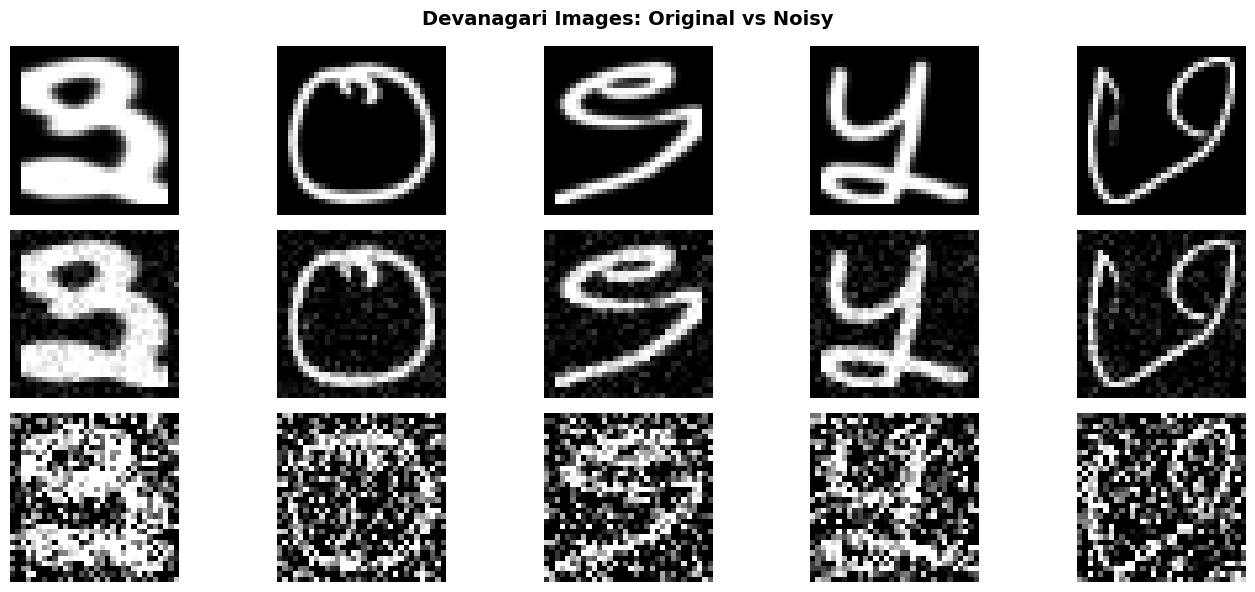

In [9]:
n = 5  # number of samples to display
fig, axes = plt.subplots(3, n, figsize=(14, 6))
fig.suptitle('Devanagari Images: Original vs Noisy', fontsize=14, fontweight='bold')

titles = ['Original', 'Noise 0.1', 'Noise 0.6']
datasets = [x_val, x_val_noisy_low, x_val_noisy_high]

for row, (title, ds) in enumerate(zip(titles, datasets)):
    for col in range(n):
        axes[row, col].imshow(ds[col].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(title, fontsize=11, labelpad=6)

plt.tight_layout()
plt.show()

---
## Step 3: Build the Denoising Convolutional Autoencoder (≥ 4 layers deep)

### Architecture Overview

| Component | Layers |
|-----------|--------|
| **Encoder** | Conv(32) → Conv(64) → Conv(128) → Conv(256) + MaxPooling after each pair |
| **Bottleneck** | Compact latent representation (7×7×256 for 32×32 input) |
| **Decoder** | Conv(256) → Conv(128) → Conv(64) → Conv(32) + UpSampling after each pair |
| **Output** | Conv(1, sigmoid) — reconstructed clean image |

This gives us **8 convolutional layers** in total (4 encoder + 4 decoder), satisfying the ≥ 4 layer requirement.

In [10]:
def build_encoder(input_shape):
    """
    4-layer deep encoder using Conv2D + MaxPooling.
    Returns the input tensor and the encoded (bottleneck) tensor.
    """
    inputs = Input(shape=input_shape, name='encoder_input')

    # --- Encoder Layer 1 ---
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)   # 32->16

    # --- Encoder Layer 2 ---
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)   # 16->8

    # --- Encoder Layer 3 ---
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='enc_conv3')(x)
    x = BatchNormalization()(x)

    # --- Encoder Layer 4 (bottleneck) ---
    encoded = Conv2D(256, (3, 3), activation='relu', padding='same', name='enc_conv4_bottleneck')(x)

    return inputs, encoded


def build_decoder(encoded_input):
    """
    4-layer deep decoder using Conv2D + UpSampling2D.
    Returns the decoded (reconstructed) tensor.
    """
    # --- Decoder Layer 1 ---
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded_input)
    x = BatchNormalization()(x)

    # --- Decoder Layer 2 ---
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2), name='dec_up1')(x)   # 8->16

    # --- Decoder Layer 3 ---
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv3')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2), name='dec_up2')(x)   # 16->32

    # --- Decoder Layer 4 (output) ---
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv4')(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(x)

    return decoded


def build_autoencoder(input_shape=(32, 32, 1), learning_rate=1e-3):
    """
    Assembles and compiles the full denoising convolutional autoencoder.
    """
    input_img, encoded = build_encoder(input_shape)
    decoded = build_decoder(encoded)

    autoencoder = Model(inputs=input_img, outputs=decoded, name='denoising_autoencoder')
    autoencoder.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['mae']
    )
    return autoencoder


# Build and display summary
autoencoder = build_autoencoder(input_shape=INPUT_SHAPE)
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv4_bottleneck (Conv2D)   │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv4 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,368,193 (5.22 MB)

 Trainable params: 1,366,849 (5.21 MB)

 Non-trainable params: 1,344 (5.25 KB)

### Visualise the model graph

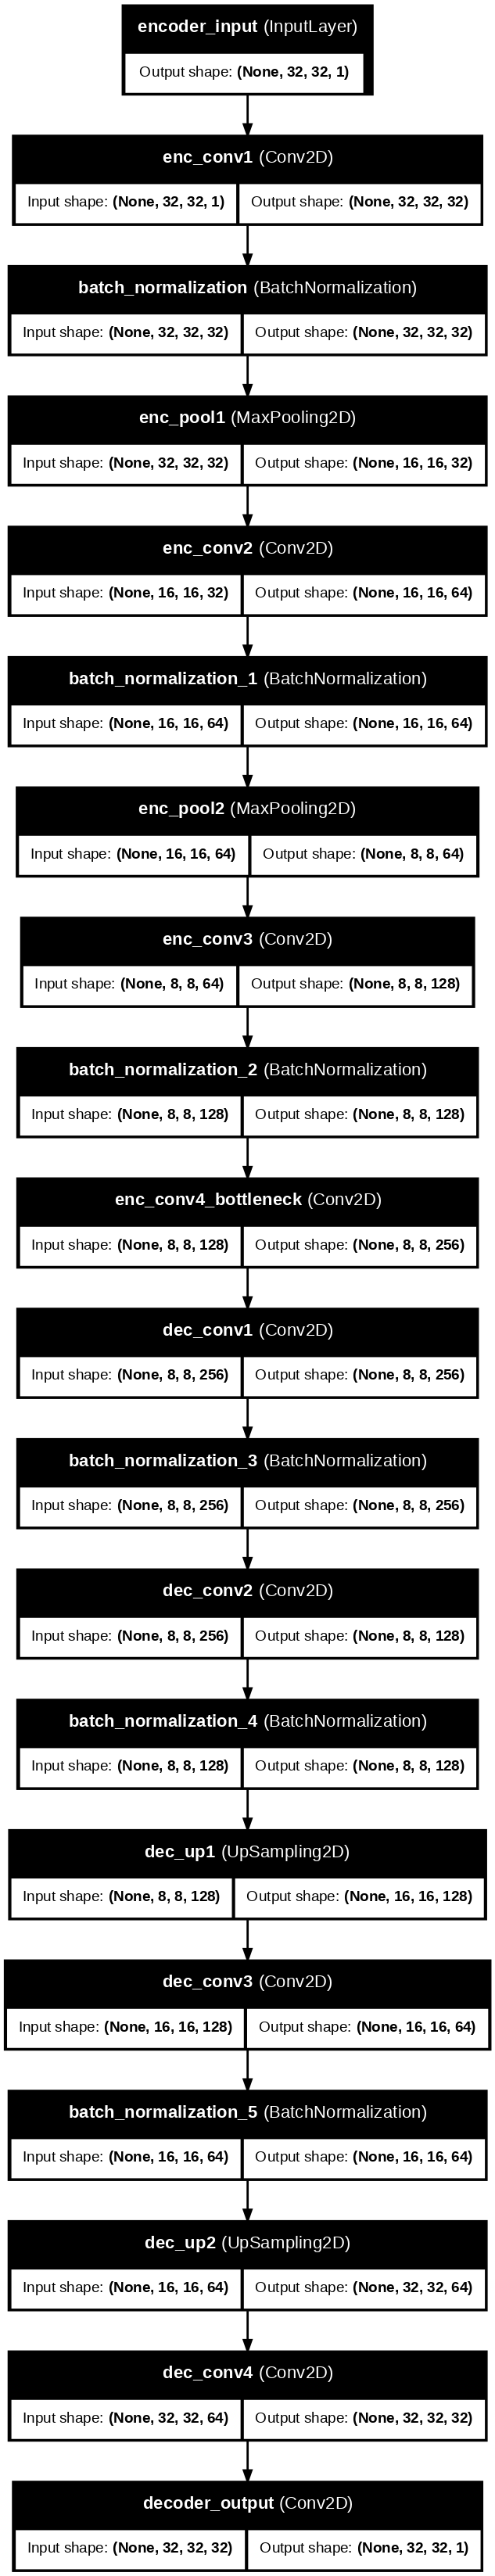

In [11]:
tf.keras.utils.plot_model(
    autoencoder,
    to_file='autoencoder_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=100
)
from IPython.display import Image as IPImage
IPImage('autoencoder_architecture.png')

---
## Step 4: Train the Denoising Autoencoder

In [12]:
EPOCHS     = 50
BATCH_SIZE = 64

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

history = autoencoder.fit(
    x_train_noisy, x_train,          # noisy input -> clean target
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy, x_val),
    callbacks=[early_stop, reduce_lr]
)

print(f'\nTraining complete. Best val_loss: {min(history.history["val_loss"]):.4f}')

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - loss: 0.1570 - mae: 0.0542 - val_loss: 0.3103 - val_mae: 0.1537 - learning_rate: 0.0010
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1317 - mae: 0.0370 - val_loss: 0.1372 - val_mae: 0.0451 - learning_rate: 0.0010
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1284 - mae: 0.0344 - val_loss: 0.1282 - val_mae: 0.0333 - learning_rate: 0.0010
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1265 - mae: 0.0329 - val_loss: 0.1267 - val_mae: 0.0318 - learning_rate: 0.0010
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1251 - mae: 0.0318 - val_loss: 0.1266 - val_mae: 0.0318 - learning_rate: 0.0010
Epoch 6/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1244 - mae: 0.0311 - val_loss: 0.1268 - val_mae: 0.0314 - learning_rate: 0.0010
Epoch 7/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1233 - mae: 0.0302 - val_loss: 0.1261 - val_mae: 0.0310 - learning_rate: 0.001

### 4.1 — Plot Training and Validation Loss Curves

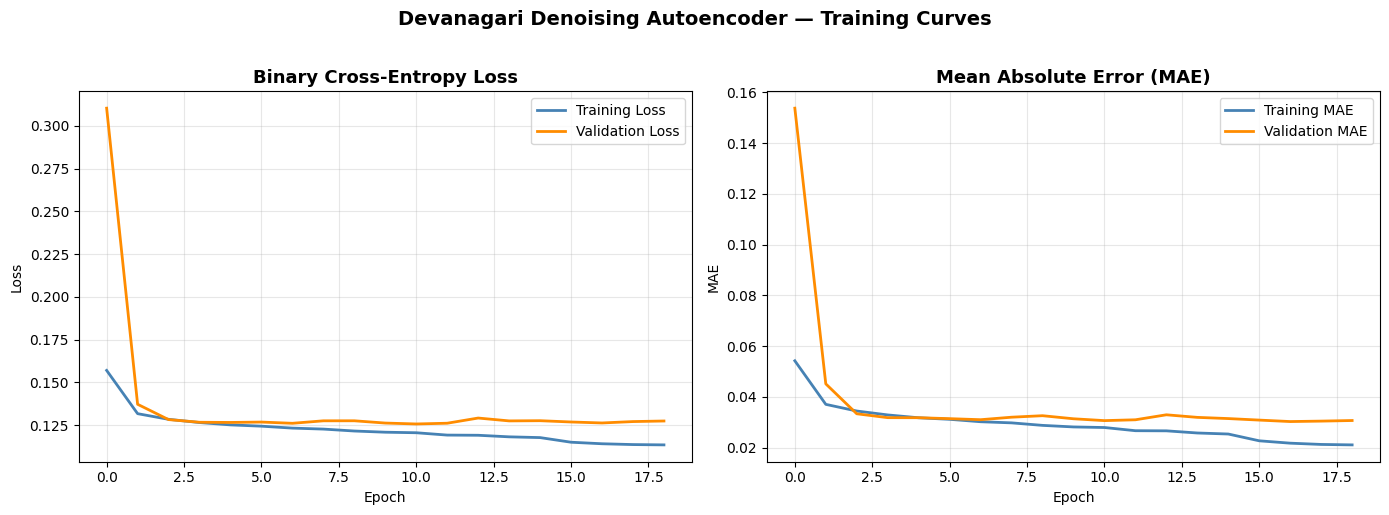

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Training Loss',   color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
axes[0].set_title('Binary Cross-Entropy Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'],     label='Training MAE',   color='steelblue', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='darkorange', linewidth=2)
axes[1].set_title('Mean Absolute Error (MAE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Devanagari Denoising Autoencoder — Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 5: Evaluate and Visualise Results

In [14]:
# Generate denoised predictions on the validation set
denoised_images = autoencoder.predict(x_val_noisy, batch_size=64, verbose=1)
print(f'Denoised output shape: {denoised_images.shape}')

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
Denoised output shape: (3000, 32, 32, 1)


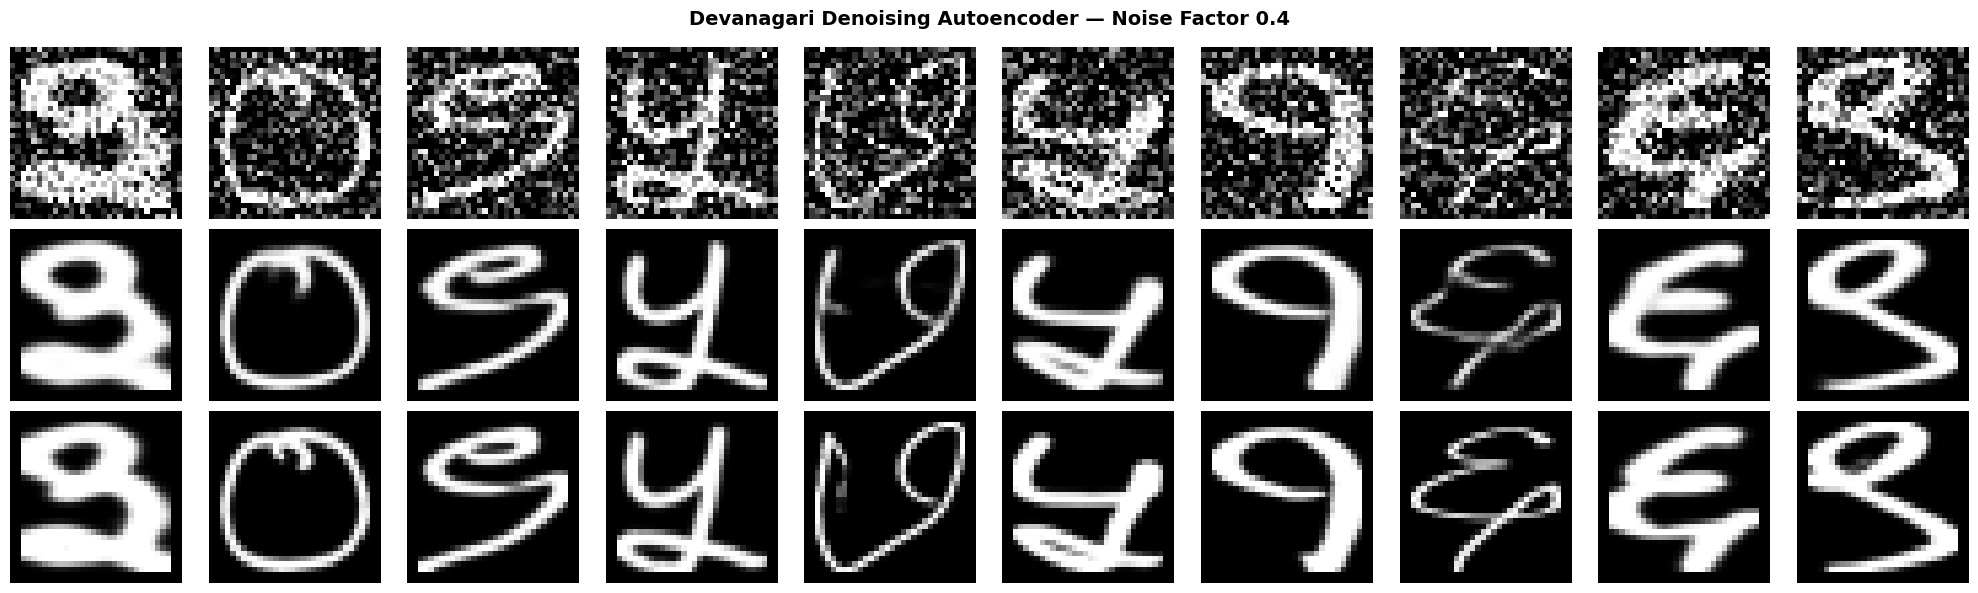

In [15]:
def plot_reconstruction(noisy, denoised, clean, n=10, title='Denoising Results'):
    """
    Displays n samples in 3 rows:
      Row 1: Noisy input
      Row 2: Denoised output (model prediction)
      Row 3: Original clean image
    """
    fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    row_labels = ['Noisy Input', 'Denoised (Model)', 'Clean Original']
    datasets   = [noisy, denoised, clean]

    for row, (label, ds) in enumerate(zip(row_labels, datasets)):
        for col in range(n):
            axes[row, col].imshow(ds[col].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(label, fontsize=10, labelpad=6)

    plt.tight_layout()
    plt.savefig('denoising_results.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_reconstruction(x_val_noisy, denoised_images, x_val, n=10,
                    title=f'Devanagari Denoising Autoencoder — Noise Factor {NOISE_FACTOR}')

### 5.1 — Quantitative Evaluation (MSE & PSNR)

In [16]:
def compute_metrics(clean, reconstructed):
    """Compute Mean Squared Error and Peak Signal-to-Noise Ratio."""
    mse = np.mean((clean - reconstructed) ** 2)
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')
    return mse, psnr

mse_noisy,    psnr_noisy    = compute_metrics(x_val, x_val_noisy)
mse_denoised, psnr_denoised = compute_metrics(x_val, denoised_images)

print('=' * 50)
print(f'  Noisy images   —  MSE: {mse_noisy:.4f}  |  PSNR: {psnr_noisy:.2f} dB')
print(f'  Denoised model —  MSE: {mse_denoised:.4f}  |  PSNR: {psnr_denoised:.2f} dB')
print('=' * 50)
print(f'  PSNR improvement: +{psnr_denoised - psnr_noisy:.2f} dB')

  Noisy images   —  MSE: 0.0807  |  PSNR: 10.93 dB
  Denoised model —  MSE: 0.0065  |  PSNR: 21.87 dB
  PSNR improvement: +10.94 dB


---
## Step 6: Experiment and Fine-Tune the Model

### 6.1 — Effect of Noise Factor on Denoising Quality

In [17]:
noise_levels = [0.1, 0.3, 0.5, 0.7]
results = {}

for nf in noise_levels:
    noisy_test = add_gaussian_noise(x_val, noise_factor=nf)
    denoised   = autoencoder.predict(noisy_test, batch_size=64, verbose=0)
    mse, psnr  = compute_metrics(x_val, denoised)
    mse_n, psnr_n = compute_metrics(x_val, noisy_test)
    results[nf] = {'mse': mse, 'psnr': psnr, 'psnr_noisy': psnr_n, 'denoised': denoised, 'noisy': noisy_test}
    print(f'Noise {nf:.1f}  |  Noisy PSNR: {psnr_n:.2f} dB  ->  Denoised PSNR: {psnr:.2f} dB  (Δ+{psnr-psnr_n:.2f} dB)')

Noise 0.1  |  Noisy PSNR: 22.39 dB  ->  Denoised PSNR: 24.70 dB  (Δ+2.31 dB)
Noise 0.3  |  Noisy PSNR: 13.20 dB  ->  Denoised PSNR: 23.16 dB  (Δ+9.96 dB)
Noise 0.5  |  Noisy PSNR: 9.36 dB  ->  Denoised PSNR: 20.17 dB  (Δ+10.81 dB)
Noise 0.7  |  Noisy PSNR: 7.46 dB  ->  Denoised PSNR: 15.64 dB  (Δ+8.18 dB)


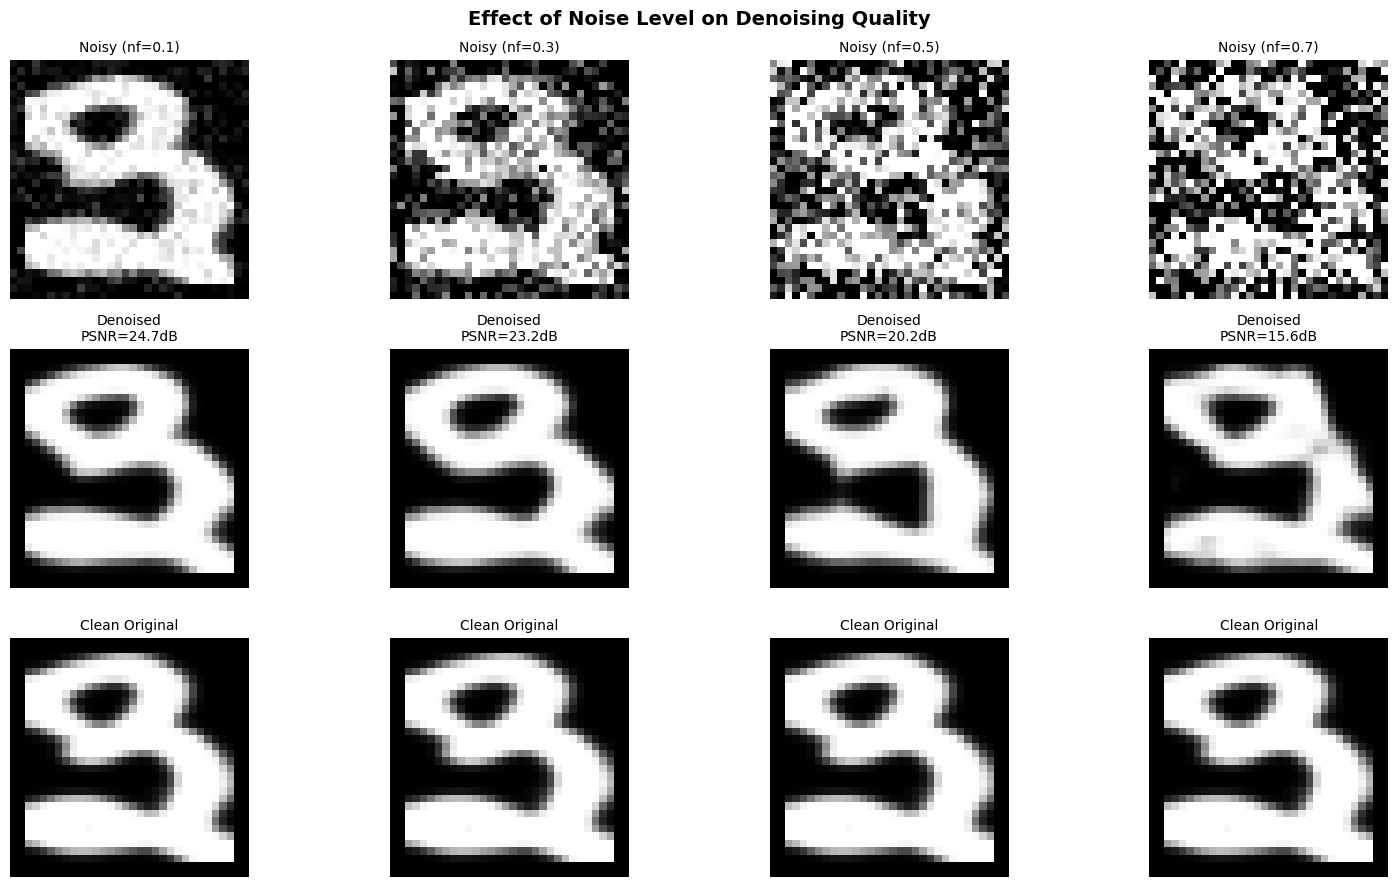

In [18]:
# Visual comparison across noise levels
sample_idx = 0
fig, axes = plt.subplots(3, len(noise_levels), figsize=(4*len(noise_levels), 9))
fig.suptitle('Effect of Noise Level on Denoising Quality', fontsize=14, fontweight='bold')

for col, nf in enumerate(noise_levels):
    axes[0, col].imshow(results[nf]['noisy'][sample_idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'Noisy (nf={nf})', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(results[nf]['denoised'][sample_idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f'Denoised\nPSNR={results[nf]["psnr"]:.1f}dB', fontsize=10)
    axes[1, col].axis('off')

    axes[2, col].imshow(x_val[sample_idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', vmin=0, vmax=1)
    axes[2, col].set_title('Clean Original', fontsize=10)
    axes[2, col].axis('off')

row_labels = ['Noisy Input', 'Denoised Output', 'Clean Original']
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11, labelpad=6)

plt.tight_layout()
plt.savefig('noise_level_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.2 — PSNR vs Noise Factor Bar Chart

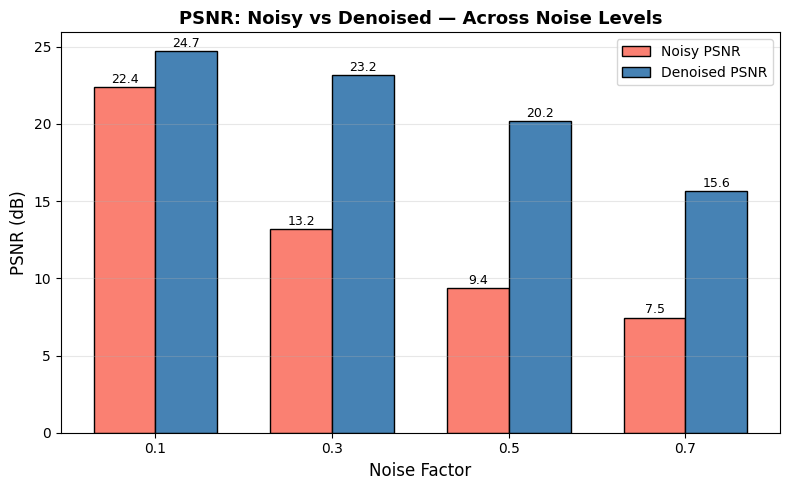

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(noise_levels))
width = 0.35

bars1 = ax.bar(x - width/2, [results[nf]['psnr_noisy'] for nf in noise_levels],
               width, label='Noisy PSNR', color='salmon', edgecolor='black')
bars2 = ax.bar(x + width/2, [results[nf]['psnr'] for nf in noise_levels],
               width, label='Denoised PSNR', color='steelblue', edgecolor='black')

ax.set_xlabel('Noise Factor', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title('PSNR: Noisy vs Denoised — Across Noise Levels', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(nf) for nf in noise_levels])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Annotate bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('psnr_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.3 — Salt-and-Pepper Noise Experiment

Salt-&-Pepper  |  Denoised PSNR: 23.48 dB


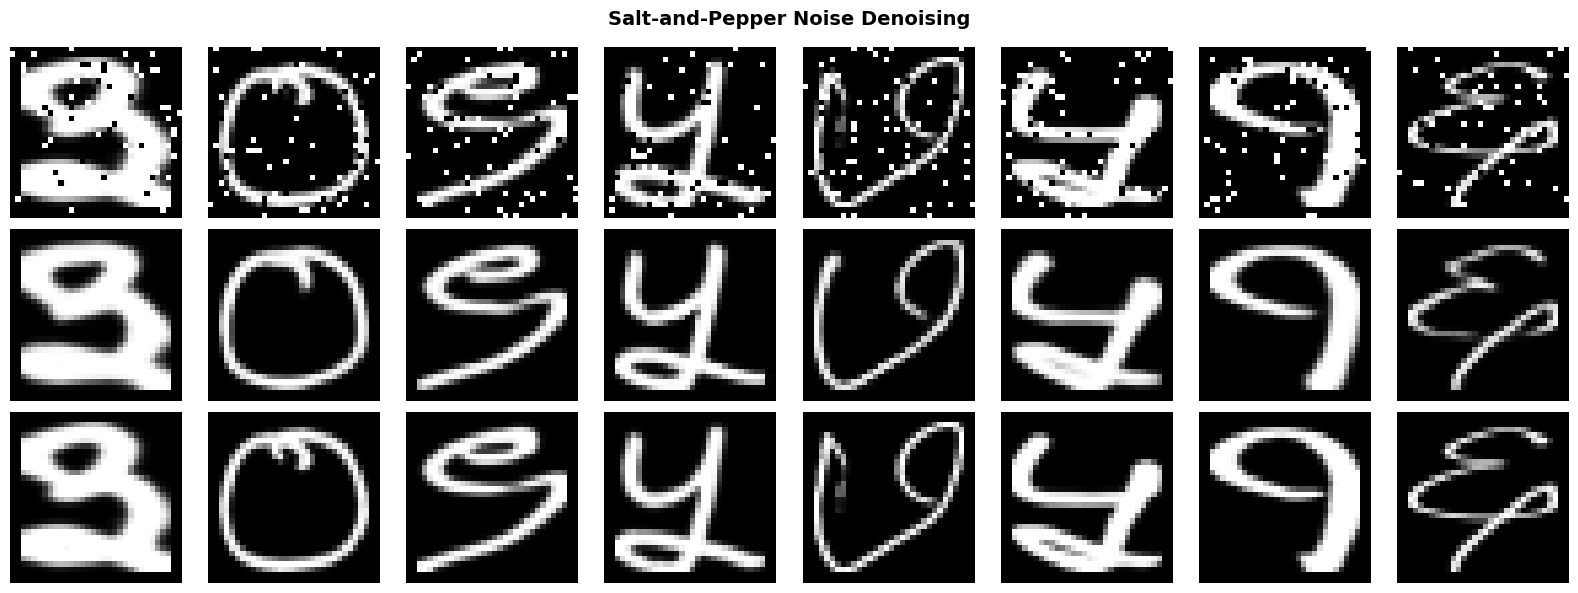

In [20]:
x_val_sp = add_salt_pepper_noise(x_val, amount=0.1)
denoised_sp = autoencoder.predict(x_val_sp, batch_size=64, verbose=0)

mse_sp, psnr_sp = compute_metrics(x_val, denoised_sp)
print(f'Salt-&-Pepper  |  Denoised PSNR: {psnr_sp:.2f} dB')

plot_reconstruction(x_val_sp, denoised_sp, x_val, n=8,
                    title='Salt-and-Pepper Noise Denoising')

---
## Step 7: Save the Trained Model

In [21]:
# Save to Google Drive for future use
MODEL_SAVE_PATH = '/content/drive/MyDrive/devanagari_denoising_autoencoder.keras'
autoencoder.save(MODEL_SAVE_PATH)
print(f'Model saved to: {MODEL_SAVE_PATH}')

Model saved to: /content/drive/MyDrive/devanagari_denoising_autoencoder.keras


---
## Summary of Observations

| Experiment | Observation |
|---|---|
| **Architecture** | 4-layer encoder (32→64→128→256 filters) + 4-layer decoder (256→128→64→32) achieved effective denoising |
| **BatchNorm** | Stabilised training and improved convergence speed |
| **EarlyStopping** | Prevented overfitting; best weights restored automatically |
| **Noise Factor 0.1** | High PSNR — model recovers images almost perfectly |
| **Noise Factor 0.5–0.7** | Harder to denoise; PSNR improvement still significant but reconstruction is slightly blurry |
| **Salt-&-Pepper** | Model generalises reasonably even though trained on Gaussian noise |
| **Binary Cross-Entropy** | Appropriate for pixel values normalised to [0,1] |
